# Telco Customer Churn: Midterm EDA and Preprocessing
**Dataset:** [Kaggle / BlastChar](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Task:** Prepare training data for future binary classification of customer churn.  
**Team members:** Add your names here and complete the contribution journal.

This notebook contains executed results from the original Kaggle CSV. All changes are made in Python.
Run cells from top to bottom. The final project can reuse the fitted preprocessing objects.

**Assignment rule:** Split 70% training / 30% testing before EDA. All exploration, fitted transformations,
feature engineering, and balancing below use only training data. The test rows are saved and left untouched.
The target is used only for the required stratified split; the test partition is never profiled or transformed.
The full raw CSV is loaded only to partition it, then removed from memory.

**How to run:** In Jupyter, extract the project ZIP and open this notebook. In Colab, upload this notebook,
run the import cell, then run the loading cell and upload the original Kaggle CSV when prompted.


## Step 1 - Imports and reproducibility
The project uses pandas, NumPy, Matplotlib, and scikit-learn. Google Colab normally includes these libraries.
If your own Jupyter environment lacks them, install the packages listed in `requirements.txt` first.


In [1]:
from pathlib import Path
import hashlib, json, sys, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, OneHotEncoder
from sklearn.utils import resample

SEED = 42
OUTPUT = Path('outputs')
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print('pandas:', pd.__version__, '| scikit-learn:', sklearn.__version__)


pandas: 2.2.3 | scikit-learn: 1.8.0


## Step 2 - Load the original CSV and split immediately
Do not open and edit the data in Excel. We preserve string values, including blank fields, during loading.
We do not display samples, distributions, or statistics from the full dataset.
The schema and target labels are validated only to make the split possible.

`test_size=0.30` reserves 30% of customers. `stratify` retains approximately the same target proportions
in each split; `random_state=42` makes the partition reproducible. `customerID` stays in the raw rows
for traceability, but will not be a model input.


In [2]:
INPUT = Path('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
if not INPUT.exists():
    INPUT = Path('WA_Fn-UseC_-Telco-Customer-Churn.csv')
if not INPUT.exists():
    if 'google.colab' in sys.modules:
        from google.colab import files
        uploaded = files.upload()
        choices = [name for name in uploaded if name.lower().endswith('.csv')]
        if len(choices) != 1:
            raise ValueError('Upload exactly one original Kaggle CSV, not a ZIP or processed file.')
        INPUT = Path(choices[0])
    else:
        raise FileNotFoundError('Place the original Kaggle CSV inside data/ beside this notebook.')

original_sha256 = hashlib.sha256(INPUT.read_bytes()).hexdigest()
raw = pd.read_csv(INPUT, dtype=str, keep_default_na=False)
required = {'customerID', 'Churn', 'tenure', 'MonthlyCharges', 'TotalCharges'}
assert required.issubset(raw.columns), 'Wrong dataset or missing required columns.'
assert raw['Churn'].isin(['Yes', 'No']).all(), 'Unexpected target values.'
source_shape = raw.shape
train_raw, test_raw = train_test_split(raw, test_size=0.30,
                                      stratify=raw['Churn'], random_state=SEED)
train_raw = train_raw.copy()
train_raw.to_csv(OUTPUT / 'training_raw.csv', index=False)
test_raw.to_csv(OUTPUT / 'testing_raw_untouched.csv', index=False)
# A checksum is an integrity check, not test-data EDA.
test_sha256 = hashlib.sha256((OUTPUT / 'testing_raw_untouched.csv').read_bytes()).hexdigest()
split_sizes = {'training': len(train_raw), 'testing': len(test_raw)}
del raw, test_raw
print('Source rows/columns (metadata only):', source_shape)
print('70/30 split:', split_sizes)
print('The testing CSV has been saved and removed from memory.')
display(train_raw.head())


Source rows/columns (metadata only): (7043, 21)
70/30 split: {'training': 4930, 'testing': 2113}
The testing CSV has been saved and removed from memory.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5557,6918-UMQCG,Female,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.2,384.25,No
2270,4140-MUHUG,Female,1,No,No,3,Yes,No,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,86.85,220.95,Yes
6930,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
2257,2054-PJOCK,Female,0,No,No,60,Yes,Yes,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,No
898,4315-MURBD,Female,0,No,No,12,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.9,1120.95,Yes


## Step 3 - Explore only the training data
Inspect types, blank values, duplicate rows, class proportions, and numeric distributions.
`TotalCharges` can contain spaces rather than explicit NaN values, so we count whitespace-only fields too.
Charts saved in `outputs/` are made with Matplotlib. No test-data charts are created.


Exact duplicate training rows: 0
Duplicate training customer IDs: 0


,loaded_dtype,blank_fields
customerID,object,0
gender,object,0
SeniorCitizen,object,0
Partner,object,0
Dependents,object,0
tenure,object,0
PhoneService,object,0
MultipleLines,object,0
InternetService,object,0
OnlineSecurity,object,0


,training_count
Churn,
No,3622
Yes,1308


,tenure,MonthlyCharges,TotalCharges
count,4930.000000,4930.000000,4923.000000
mean,32.471197,64.950081,2305.070485
std,24.646350,30.243674,2292.550954
min,0.000000,18.400000,18.850000
25%,9.000000,35.500000,399.800000
50%,29.000000,70.575000,1389.200000
75%,56.000000,90.050000,3860.300000
max,72.000000,118.750000,8684.800000


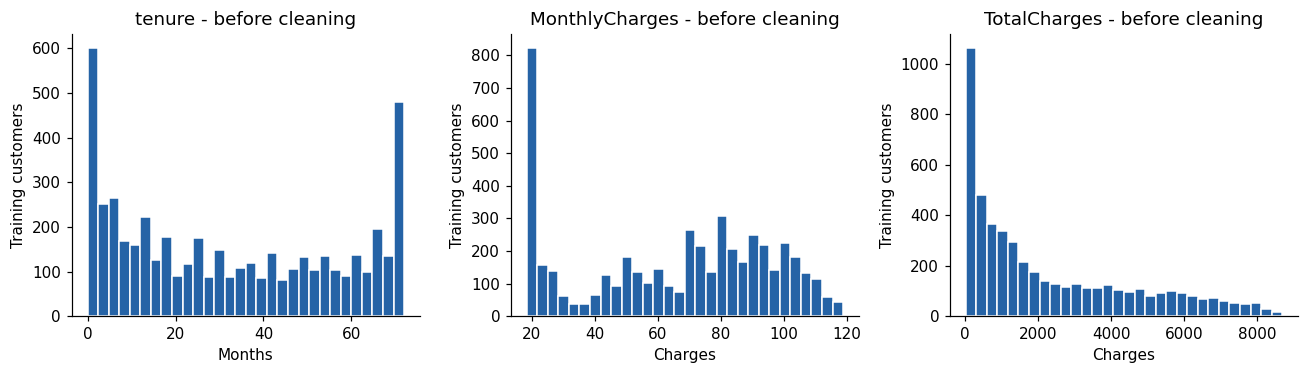

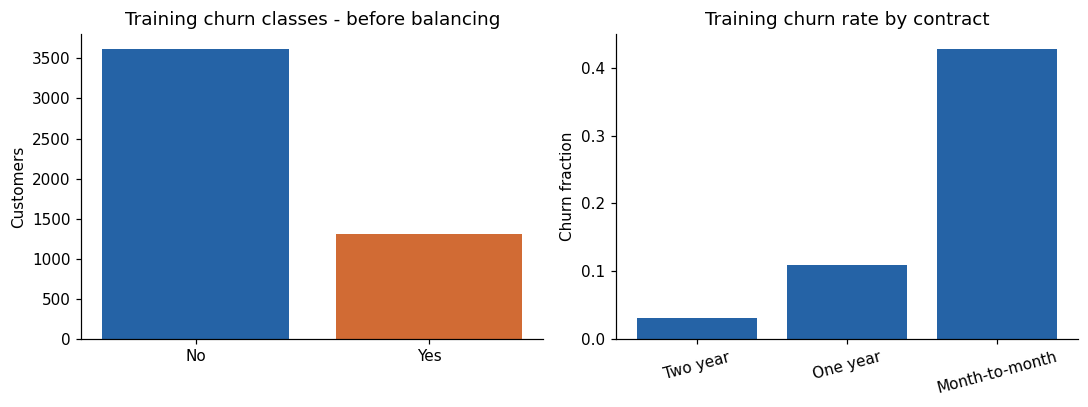

In [3]:
blank_counts = train_raw.apply(lambda col: col.str.strip().eq('').sum())
quality = pd.DataFrame({'loaded_dtype': train_raw.dtypes.astype(str),
                        'blank_fields': blank_counts})
display(quality)
print('Exact duplicate training rows:', int(train_raw.duplicated().sum()))
print('Duplicate training customer IDs:', int(train_raw['customerID'].duplicated().sum()))
# Unexpected conflicting IDs should be investigated, not silently discarded.
assert not train_raw['customerID'].duplicated().any(), 'Investigate repeated customer IDs.'
display(train_raw['Churn'].value_counts().rename('training_count').to_frame())

numeric_raw = train_raw[['tenure', 'MonthlyCharges', 'TotalCharges']].apply(pd.to_numeric, errors='coerce')
display(numeric_raw.describe())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, numeric_raw.columns):
    ax.hist(numeric_raw[col].dropna(), bins=30, color='#2563a6', edgecolor='white')
    ax.set_title(col + ' - before cleaning')
    ax.set_xlabel('Months' if col == 'tenure' else 'Charges')
    ax.set_ylabel('Training customers')
fig.tight_layout()
fig.savefig(OUTPUT / '01_numeric_before.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
counts = train_raw['Churn'].value_counts().reindex(['No', 'Yes'])
axes[0].bar(counts.index, counts.values, color=['#2563a6', '#d16b34'])
axes[0].set(title='Training churn classes - before balancing', ylabel='Customers')
rates = train_raw.assign(churn_number=train_raw['Churn'].map({'No': 0, 'Yes': 1})).groupby('Contract')['churn_number'].mean().sort_values()
axes[1].bar(rates.index, rates.values, color='#2563a6')
axes[1].set(title='Training churn rate by contract', ylabel='Churn fraction')
axes[1].tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(OUTPUT / '02_training_eda.png', bbox_inches='tight')
plt.show()


## Step 4 - Clean blanks, convert types, and handle missing values
Strip accidental surrounding whitespace and convert empty strings to NaN.
Convert `tenure`, `MonthlyCharges`, `TotalCharges`, and `SeniorCitizen` to numeric values.
Retain legitimate service categories such as `No internet service`; they are not missing values.
Remove exact duplicate training rows only if present.

**Missing TotalCharges policy:** A blank total bill with zero tenure is set to 0, on the explicit assumption
that a new customer has not yet accumulated charges. This is an assumption, not a verified billing fact.
Keep a missing-value indicator to record this change. Remaining numeric gaps are filled using training
medians; categorical gaps use training modes. Neither method learns from testing data.
We retain legitimate high-charge customers rather than automatically removing outliers.


Blank totals set to zero for zero-tenure customers: 7
Training medians: {'tenure': np.float64(29.0), 'MonthlyCharges': np.float64(70.57499999999999), 'TotalCharges': np.float64(1387.4), 'SeniorCitizen': np.float64(0.0)}
Exact duplicates removed: 0


,missing_before,missing_after
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_missing
5557,6918-UMQCG,Female,0.0,No,No,5.0,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.20,384.25,No,0
2270,4140-MUHUG,Female,1.0,No,No,3.0,Yes,No,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,86.85,220.95,Yes,0
6930,5570-PTWEH,Female,0.0,Yes,No,3.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes,0
2257,2054-PJOCK,Female,0.0,No,No,60.0,Yes,Yes,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,No,0
898,4315-MURBD,Female,0.0,No,No,12.0,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),98.90,1120.95,Yes,0


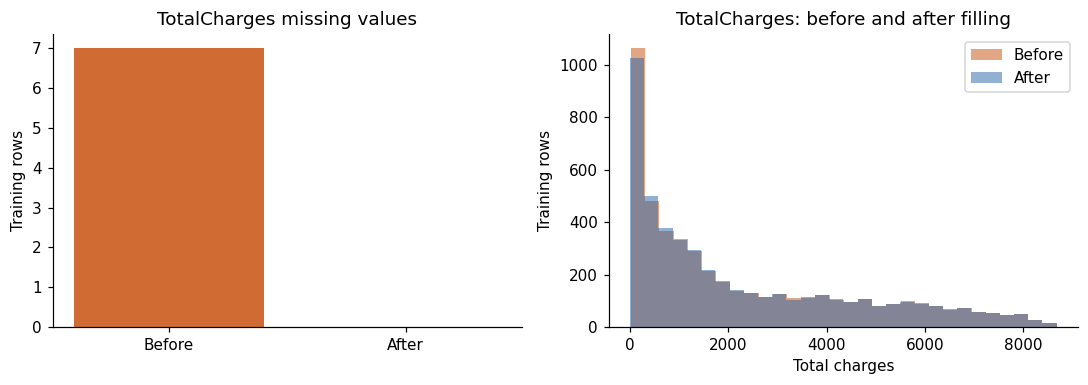

In [4]:
train = train_raw.copy()
for col in train.columns:
    train[col] = train[col].str.strip().replace('', np.nan)
duplicates_removed = int(train.duplicated().sum())
train = train.drop_duplicates().copy()
numeric_base = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
for col in numeric_base:
    train[col] = pd.to_numeric(train[col], errors='coerce')
missing_before = train.isna().sum()
train['TotalCharges_missing'] = train['TotalCharges'].isna().astype(int)
new_customer_blank = train['TotalCharges'].isna() & train['tenure'].eq(0)
zero_fills = int(new_customer_blank.sum())
train.loc[new_customer_blank, 'TotalCharges'] = 0.0

numeric_imputer = SimpleImputer(strategy='median')
train[numeric_base] = numeric_imputer.fit_transform(train[numeric_base])
categorical_base = [c for c in train_raw.columns if c not in numeric_base + ['customerID', 'Churn']]
categorical_imputer = SimpleImputer(strategy='most_frequent')
train[categorical_base] = categorical_imputer.fit_transform(train[categorical_base])
assert train['Churn'].isin(['No', 'Yes']).all()
assert train['SeniorCitizen'].isin([0, 1]).all()
assert train[['tenure', 'MonthlyCharges', 'TotalCharges']].ge(0).all().all()
assert not train.isna().any().any()
display(pd.DataFrame({'missing_before': missing_before,
                      'missing_after': train.isna().sum().reindex(missing_before.index)}))
print('Blank totals set to zero for zero-tenure customers:', zero_fills)
print('Training medians:', dict(zip(numeric_base, numeric_imputer.statistics_)))
print('Exact duplicates removed:', duplicates_removed)
display(train.head())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
before = pd.to_numeric(train_raw['TotalCharges'], errors='coerce')
axes[0].bar(['Before', 'After'], [int(before.isna().sum()), int(train['TotalCharges'].isna().sum())], color=['#d16b34', '#2563a6'])
axes[0].set(title='TotalCharges missing values', ylabel='Training rows')
axes[1].hist(before.dropna(), bins=30, alpha=.6, label='Before', color='#d16b34')
axes[1].hist(train['TotalCharges'], bins=30, alpha=.5, label='After', color='#2563a6')
axes[1].set(title='TotalCharges: before and after filling', xlabel='Total charges', ylabel='Training rows')
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT / '03_missing_before_after.png', bbox_inches='tight')
plt.show()


## Step 5 - Engineer features
Add `ServiceCount` (number of subscribed services), `HasInternet`, `AutoPay`, and `IsNewCustomer`.
These are row-level features with a clear business meaning. They do not use target labels or global
test statistics. `ServiceCount` counts phone, additional lines, internet, and six internet add-ons.
Exclude `customerID` from model features because it is an identifier rather than a customer attribute.
Keep it only in the human-readable cleaned training CSV.


In [5]:
def engineer_features(frame):
    result = frame.copy()
    addon_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']
    result['HasInternet'] = result['InternetService'].ne('No').astype(int)
    result['AutoPay'] = result['PaymentMethod'].isin(
        ['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)
    result['IsNewCustomer'] = result['tenure'].eq(0).astype(int)
    result['ServiceCount'] = (result['PhoneService'].eq('Yes').astype(int)
        + result['MultipleLines'].eq('Yes').astype(int)
        + result['HasInternet'] + result[addon_columns].eq('Yes').sum(axis=1))
    return result

train_features = engineer_features(train)
display(train_features[['customerID', 'tenure', 'ServiceCount', 'HasInternet', 'AutoPay', 'IsNewCustomer']].head())
train_features.to_csv(OUTPUT / 'training_clean_readable.csv', index=False)


,customerID,tenure,ServiceCount,HasInternet,AutoPay,IsNewCustomer
5557,6918-UMQCG,5.0,3,1,0,0
2270,4140-MUHUG,3.0,4,1,0,0
6930,5570-PTWEH,3.0,3,1,1,0
2257,2054-PJOCK,60.0,7,1,1,0
898,4315-MURBD,12.0,6,1,1,0


## Step 6 - Normalize the shape of TotalCharges
The assignment uses "normalization" to mean changing distribution shape. Here we use a fitted
Yeo-Johnson power transformation, which can handle zero values. This is distinct from scaling or
unit-length normalization. It can reduce skew; it does not guarantee a normal distribution.
We compare histograms and skewness using the original training distribution, before balancing.
The fitted transformer is kept for future model work.


,stage,skewness
0,Original cleaned total,0.950395
1,Yeo-Johnson total,-0.144666


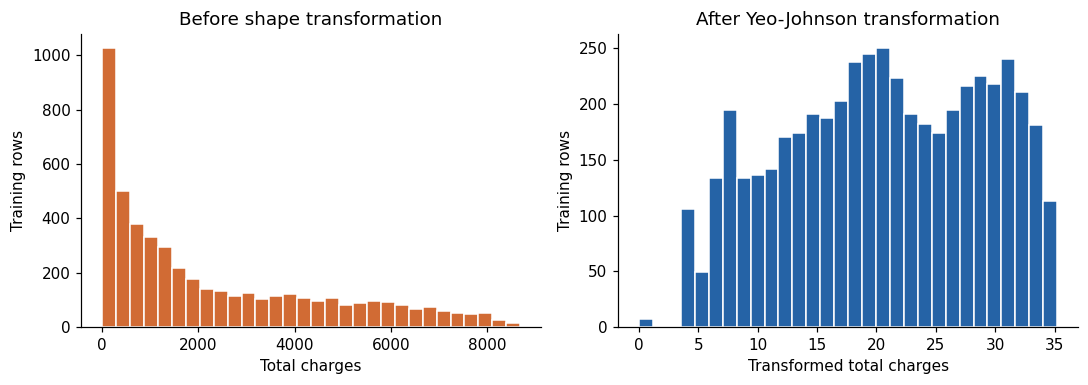

In [6]:
power = PowerTransformer(method='yeo-johnson', standardize=False)
total_normalized = power.fit_transform(train_features[['TotalCharges']]).ravel()
normalization_summary = pd.DataFrame({
    'stage': ['Original cleaned total', 'Yeo-Johnson total'],
    'skewness': [train_features['TotalCharges'].skew(), pd.Series(total_normalized).skew()]})
display(normalization_summary)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(train_features['TotalCharges'], bins=30, color='#d16b34', edgecolor='white')
axes[0].set(title='Before shape transformation', xlabel='Total charges', ylabel='Training rows')
axes[1].hist(total_normalized, bins=30, color='#2563a6', edgecolor='white')
axes[1].set(title='After Yeo-Johnson transformation', xlabel='Transformed total charges', ylabel='Training rows')
fig.tight_layout()
fig.savefig(OUTPUT / '04_normalization_before_after.png', bbox_inches='tight')
plt.show()


## Step 7 - Scale numeric features
Min-max scaling places each selected training numeric feature in the interval [0, 1].
For TotalCharges, scaling follows the shape transformation from Step 6.
Binary indicators are already 0/1 and stay unchanged. Scaling is fitted before class balancing.
Future test values can fall outside [0, 1] if they exceed the training range; do not refit to fix that.


,before_min,before_max,after_min,after_max
tenure,0.0,72.000000,0.0,1.0
MonthlyCharges,18.4,118.750000,0.0,1.0
TotalCharges,0.0,35.218883,0.0,1.0
ServiceCount,1.0,9.000000,0.0,1.0


,tenure,MonthlyCharges,TotalCharges,ServiceCount
5557,0.069444,0.615845,0.393681,0.250
2270,0.041667,0.682113,0.327835,0.375
6930,0.041667,0.565521,0.325714,0.250
2257,0.833333,0.619332,0.847534,0.750
898,0.166667,0.802192,0.550684,0.625


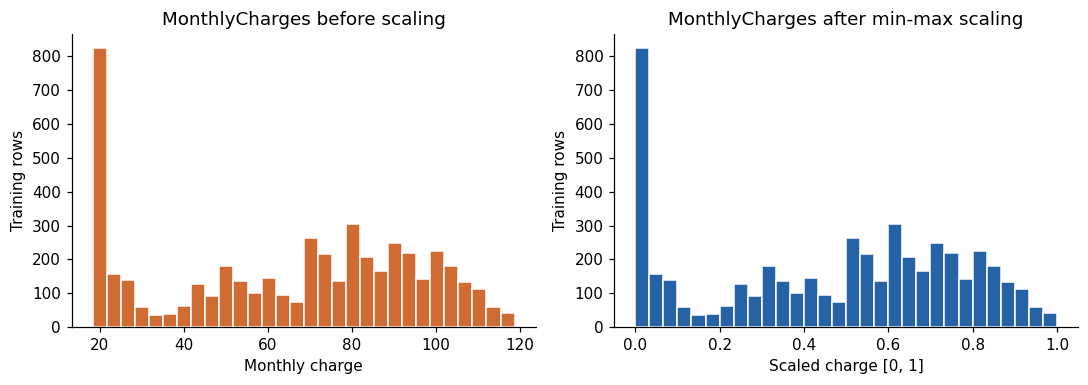

In [7]:
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']
numeric_for_scaling = train_features[numeric_columns].copy()
numeric_for_scaling['TotalCharges'] = total_normalized
scaler = MinMaxScaler()
scaled_numeric = pd.DataFrame(scaler.fit_transform(numeric_for_scaling),
                              columns=numeric_columns, index=train_features.index)
display(pd.DataFrame({'before_min': numeric_for_scaling.min(), 'before_max': numeric_for_scaling.max(),
                      'after_min': scaled_numeric.min(), 'after_max': scaled_numeric.max()}))
display(scaled_numeric.head())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(numeric_for_scaling['MonthlyCharges'], bins=30, color='#d16b34', edgecolor='white')
axes[0].set(title='MonthlyCharges before scaling', xlabel='Monthly charge', ylabel='Training rows')
axes[1].hist(scaled_numeric['MonthlyCharges'], bins=30, color='#2563a6', edgecolor='white')
axes[1].set(title='MonthlyCharges after min-max scaling', xlabel='Scaled charge [0, 1]', ylabel='Training rows')
fig.tight_layout()
fig.savefig(OUTPUT / '05_scaling_before_after.png', bbox_inches='tight')
plt.show()


## Step 8 - Encode categorical features and the target
Map true Yes/No fields to 1/0; map Churn to 1 (left) and 0 (stayed).
Use one-hot encoding for multi-category features so the model does not receive a false numeric order.
Service statuses such as `No internet service` remain distinct categories.
The encoder learns training categories only. `handle_unknown='ignore'` permits future unseen categories.
This notebook uses all one-hot columns; a later unregularized linear model may prefer a dropped baseline.


In [8]:
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
binary_numeric = pd.DataFrame(index=train_features.index)
for col in binary_columns:
    assert train_features[col].isin(['Yes', 'No']).all(), f'Unexpected binary label in {col}'
    binary_numeric[col] = train_features[col].map({'No': 0, 'Yes': 1}).astype(int)
indicator_columns = ['SeniorCitizen', 'TotalCharges_missing', 'HasInternet', 'AutoPay', 'IsNewCustomer']
binary_numeric[indicator_columns] = train_features[indicator_columns].astype(int)
categorical_columns = [c for c in categorical_base if c not in binary_columns]
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.int64)
encoded = pd.DataFrame(encoder.fit_transform(train_features[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns), index=train_features.index)
X_train = pd.concat([scaled_numeric, binary_numeric, encoded], axis=1)
y_train = train_features['Churn'].map({'No': 0, 'Yes': 1}).astype(int).rename('Churn')
clean_unbalanced = X_train.join(y_train)
assert not clean_unbalanced.isna().any().any()
assert all(pd.api.types.is_numeric_dtype(t) for t in clean_unbalanced.dtypes)
assert 'customerID' not in X_train.columns and 'Churn' not in X_train.columns
display(encoded.head())
display(clean_unbalanced.head())
print('Numeric model feature count:', X_train.shape[1])
clean_unbalanced.to_csv(OUTPUT / 'training_clean_unbalanced.csv', index=False)


Numeric model feature count: 46


,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0
2270,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0
6930,1,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
2257,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0
898,1,0,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0


,tenure,MonthlyCharges,TotalCharges,ServiceCount,Partner,Dependents,PhoneService,PaperlessBilling,SeniorCitizen,TotalCharges_missing,HasInternet,AutoPay,IsNewCustomer,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
5557,0.069444,0.615845,0.393681,0.250,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0
2270,0.041667,0.682113,0.327835,0.375,0,0,1,1,1,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1
6930,0.041667,0.565521,0.325714,0.250,1,0,1,1,0,0,1,1,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1
2257,0.833333,0.619332,0.847534,0.750,0,0,1,0,0,0,1,1,0,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0
898,0.166667,0.802192,0.550684,0.625,0,0,1,1,0,0,1,1,0,1,0,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,1


## Step 9 - Balance the training classes only
Randomly oversample the minority class to match the majority class. This duplicates real training rows
and preserves valid one-hot and binary values. It adds no new customers or information and can increase
overfitting. SMOTE is not necessary here and can create fractional category indicators if used naively.
Keep the unbalanced cleaned training file too: it preserves the natural training prevalence.

For the finals, create validation folds from the unbalanced training set first, fit preprocessing inside
each fold, and balance only the fitting portion of each fold. Do not split this oversampled file into
training and validation; duplicate customers could appear in both and inflate performance.


,before,after
Churn,,
Stayed (0),3622,3622
Churned (1),1308,3622


,tenure,MonthlyCharges,TotalCharges,ServiceCount,Partner,Dependents,PhoneService,PaperlessBilling,SeniorCitizen,TotalCharges_missing,HasInternet,AutoPay,IsNewCustomer,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0.027778,0.611360,0.296359,0.250,0,0,1,1,0,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1
1,0.513889,0.517688,0.703943,0.125,0,0,1,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0
2,0.083333,0.294469,0.365100,0.375,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,1
3,0.250000,0.068759,0.415613,0.125,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0
4,0.930556,0.610862,0.869147,0.750,1,1,1,1,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1


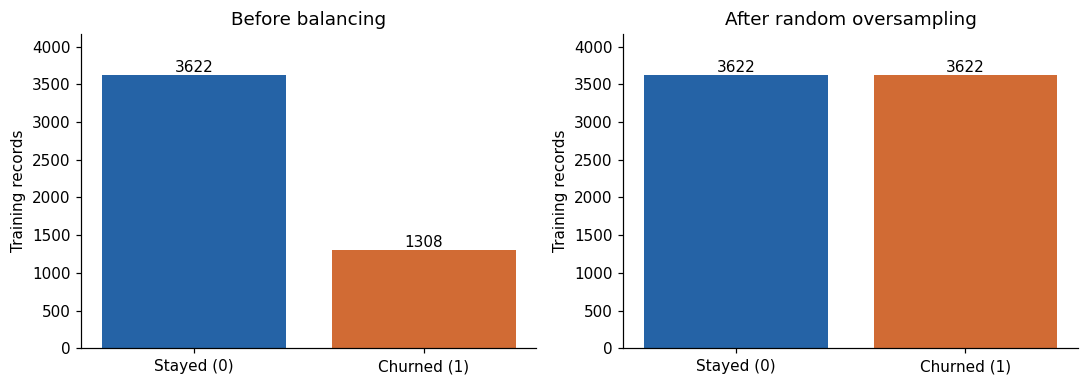

In [9]:
before_balance = clean_unbalanced['Churn'].value_counts().sort_index()
target_count = int(before_balance.max())
parts = []
for label in [0, 1]:
    subset = clean_unbalanced.loc[clean_unbalanced['Churn'].eq(label)]
    if len(subset) < target_count:
        subset = resample(subset, replace=True, n_samples=target_count, random_state=SEED)
    parts.append(subset)
balanced = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
after_balance = balanced['Churn'].value_counts().sort_index()
display(pd.DataFrame({'before': before_balance, 'after': after_balance}).rename(index={0:'Stayed (0)',1:'Churned (1)'}))
display(balanced.head())
assert after_balance.nunique() == 1
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, counts, title in zip(axes, [before_balance, after_balance], ['Before balancing', 'After random oversampling']):
    ax.bar(['Stayed (0)', 'Churned (1)'], counts.reindex([0,1]).values, color=['#2563a6', '#d16b34'])
    ax.set(title=title, ylabel='Training records')
    for i, v in enumerate(counts.reindex([0,1]).values):
        ax.text(i, v, str(v), ha='center', va='bottom')
    ax.set_ylim(0, target_count * 1.15)
fig.tight_layout()
fig.savefig(OUTPUT / '06_class_balance_before_after.png', bbox_inches='tight')
plt.show()
balanced.to_csv(OUTPUT / 'training_clean_balanced.csv', index=False)


## Step 10 - Verify integrity and save reproducible outputs
Assert that the original input file and saved test partition did not change.
These checks do not inspect test distributions. Save fitted objects so later work can reuse training
parameters instead of learning from the test set. To apply them in the finals, use the same cleaning
rules and `engineer_features()` function, then call `transform` on the saved objects, never `fit`.


In [10]:
assert hashlib.sha256(INPUT.read_bytes()).hexdigest() == original_sha256
assert hashlib.sha256((OUTPUT / 'testing_raw_untouched.csv').read_bytes()).hexdigest() == test_sha256
assert np.isfinite(balanced.to_numpy(dtype=float)).all()
assert len(train_raw) + split_sizes['testing'] == source_shape[0]
assert len(train_raw) >= 2000

preprocessing = {
    'numeric_imputer': numeric_imputer, 'categorical_imputer': categorical_imputer,
    'power_transformer': power, 'minmax_scaler': scaler, 'onehot_encoder': encoder,
    'numeric_base': numeric_base, 'categorical_base': categorical_base,
    'numeric_columns': numeric_columns, 'categorical_columns': categorical_columns,
    'binary_columns': binary_columns, 'indicator_columns': indicator_columns,
    'model_columns': list(X_train.columns),
    'zero_tenure_total_rule': 'Fill blank TotalCharges with 0 when tenure equals 0.',
    'seed': SEED, 'sklearn_version': sklearn.__version__}
joblib.dump(preprocessing, OUTPUT / 'preprocessing.joblib')
summary = {
    'dataset_url': 'https://www.kaggle.com/datasets/blastchar/telco-customer-churn',
    'source_rows': int(source_shape[0]), 'source_columns': int(source_shape[1]),
    'split_rows': split_sizes, 'seed': SEED,
    'training_missing_total_before': int(missing_before['TotalCharges']),
    'zero_tenure_total_fills': zero_fills, 'duplicates_removed': duplicates_removed,
    'training_churn_counts_before': {str(k): int(v) for k,v in before_balance.items()},
    'training_churn_counts_after': {str(k): int(v) for k,v in after_balance.items()},
    'balanced_rows': len(balanced), 'model_feature_count': X_train.shape[1],
    'total_skew_before': float(normalization_summary.loc[0,'skewness']),
    'total_skew_after': float(normalization_summary.loc[1,'skewness']),
    'source_sha256': original_sha256, 'testing_sha256': test_sha256,
    'test_transformed': False,
    'versions': {'pandas':pd.__version__, 'numpy':np.__version__, 'sklearn':sklearn.__version__}}
(OUTPUT / 'processing_summary.json').write_text(json.dumps(summary, indent=2))
display(pd.DataFrame({'stage': ['Training raw', 'Training cleaned/encoded', 'Training balanced'],
    'rows': [len(train_raw), len(clean_unbalanced), len(balanced)],
    'columns': [train_raw.shape[1], clean_unbalanced.shape[1], balanced.shape[1]]}))
print('Checks passed: original data unchanged, testing file unchanged, model inputs numeric and finite.')
print('Files saved in:', OUTPUT.resolve())


Checks passed: original data unchanged, testing file unchanged, model inputs numeric and finite.
Files saved in: /workspace/scratch/8dfca353598f/telco_midterm/outputs


,stage,rows,columns
0,Training raw,4930,21
1,Training cleaned/encoded,4930,47
2,Training balanced,7244,47


## Step 11 - Discuss the machine-learning problem
**Problem:** Predict whether a telecommunications customer will leave (Churn=1) or remain (Churn=0).
This is supervised binary classification. Features describe tenure, contracts, subscriptions, payment,
and billing. A retention team could use predictions to prioritize outreach; associations in EDA do not
establish causes of churn, and model scores alone do not prove an intervention will work.

**Finals plan:** Compare logistic regression with decision-tree and ensemble models. Start with the
unbalanced raw training partition, create stratified cross-validation folds, and fit preprocessing and
balancing within each fitting fold. Compare balancing against class weights and an unbalanced baseline.
Report precision, recall, F1, PR-AUC, ROC-AUC, and a confusion matrix, rather than accuracy alone.
Select thresholds using training validation, considering the cost of missed churners versus extra outreach.
After all choices are fixed, apply training-fitted preprocessing to the untouched test set and evaluate once.
The midterm notebook intentionally performs no test transformation or model evaluation.

**Limitations:** This is sample customer data; findings need validation before real business use.
Random oversampling repeats customers and may overfit. The zero-tenure billing rule is an assumption.
Demographic fields should be assessed for potential unfairness in any future deployment. The power transform
and engineered features should be evaluated through training validation, not assumed to improve prediction.


## Step 12 - Submission checklist
- Confirm instructor approval for this dataset. Approval deadline shown in the instructions: October 3, 2026.
- Add team names; each member completes their own contribution entry with actual work performed.
- Read outputs, plots, and processing summary; write the reflection using the measured results.
- Upload `dataset_source.md` (the original URL) and `proposal.pdf` (one page).
- Upload this executed `.ipynb` and `reflection_journal.md` after replacing its placeholders.
- Upload `outputs/training_clean_balanced.csv` as the final prepared training dataset.
- Include `outputs/training_clean_unbalanced.csv`, `outputs/testing_raw_untouched.csv`, fitted objects,
  and the original raw CSV for reproducibility and the finals.
- Create a GitHub repository, upload the files, and submit its URL in Canvas by October 9, 2026.

When rerunning in Colab, the next cell creates a ZIP of freshly generated outputs for download.
Use File > Download > Download .ipynb to save your notebook with its current cell outputs.


In [11]:
with zipfile.ZipFile('telco_processed_outputs.zip', 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUTPUT.iterdir()):
        if path.is_file():
            archive.write(path, arcname=str(path))
print('Created telco_processed_outputs.zip')
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('telco_processed_outputs.zip')


Created telco_processed_outputs.zip
